# Preprocessing

,Description,Value
0,Session id,4326
1,Original data shape,"(150, 4)"
2,Transformed data shape,"(150, 4)"
3,Numeric features,4
4,Preprocess,True
5,Imputation type,simple
6,Numeric imputation,mean
7,Categorical imputation,mode
8,CPU Jobs,-1
9,Use GPU,False


Data asli:  (150, 6)
Data setelah hapus outlier:  (142, 6)


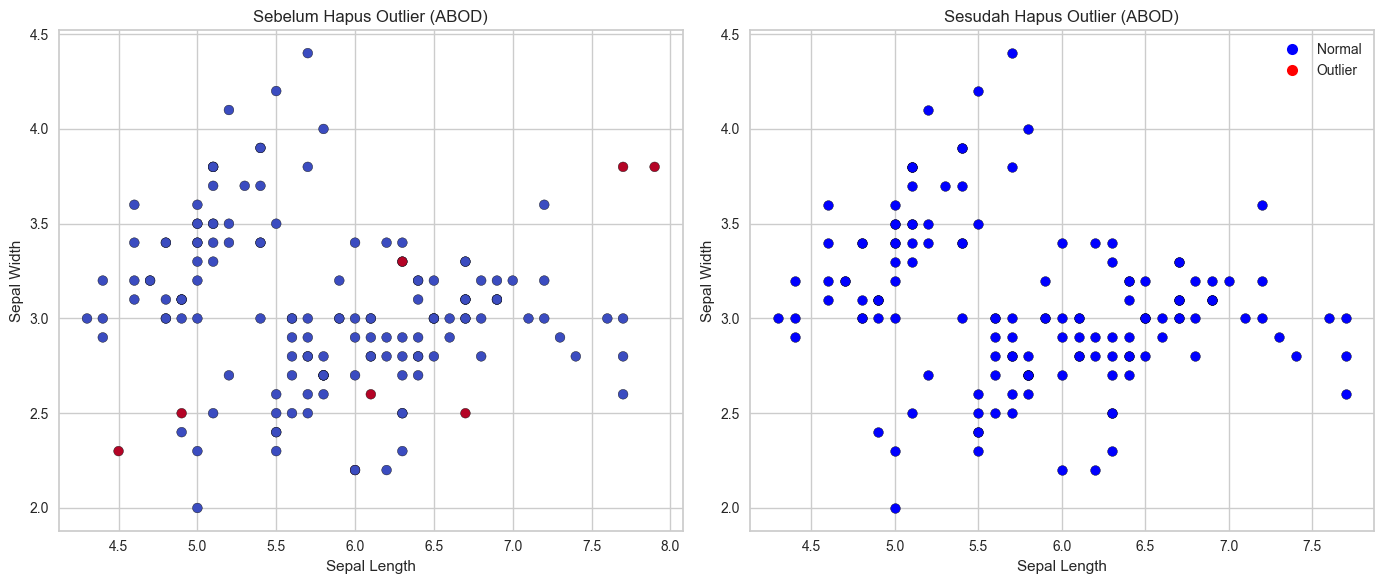

In [1]:
import pandas as pd
from pycaret.anomaly import * 
import matplotlib.pyplot as plt

# load data
data = pd.read_csv("dataset/iris.csv")
data = data.drop(columns=["iris"])

# setup data PyCaret
s = setup(data)

# membuat model dari metode
abod = create_model('abod', fraction=0.05) 
results = assign_model(abod)

# menghapus data outlier
cleaned_data = results[results["Anomaly"] == 0].copy()

print("Data asli: ", results.shape)
print("Data setelah hapus outlier: ", cleaned_data.shape)

# buat file csv baru
cleaned_data.to_csv("iris_ABOD_cleaned.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Sebelum dihapus data outlier
axes[0].scatter(
    results['sepal length'], results['sepal width'],
    c=results['Anomaly'], cmap='coolwarm', edgecolor='k'
)
axes[0].set_title("Sebelum Hapus Outlier (ABOD)")
axes[0].set_xlabel("Sepal Length")
axes[0].set_ylabel("Sepal Width")

# Sesudah dihapus data outlier
axes[1].scatter(
    cleaned_data['sepal length'], cleaned_data['sepal width'],
    c='blue', edgecolor='k'
)
axes[1].set_title("Sesudah Hapus Outlier (ABOD)")
axes[1].set_xlabel("Sepal Length")
axes[1].set_ylabel("Sepal Width")

handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='Normal',
               markerfacecolor='blue', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='Outlier',
               markerfacecolor='red', markersize=8)
]
plt.legend(handles=handles)

plt.tight_layout()
plt.show()